<a href="https://colab.research.google.com/github/indrap23/PJJDA/blob/main/latihan_KDD_99.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#setting module
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import tensorflow as tf
tf.__version__

'2.19.0'

#Problem Formulation


Membangun sebuah model detektor intrusi jaringan (network intrusion detector) yang berfungsi sebagai sistem peringatan otomatis. Model harus memiliki kemampuan prediktif untuk membedakan antara dua jenis koneksi utama:

- Koneksi "Buruk" (Intrusi/Serangan): Koneksi yang mencoba merusak, mencuri data, atau melumpuhkan jaringan.

- Koneksi "Baik" (Normal): Lalu lintas jaringan rutin yang aman.

dan mengidentifikasi kategori serangan spesifik (klasifikasi multi-kelas), seperti DoS, Probe, R2L, dan U2R.

# Data Collection

data dari https://www.kaggle.com/datasets/galaxyh/kdd-cup-1999-data

In [3]:
url = "https://raw.githubusercontent.com/indrap23/PJJDA/refs/heads/main/kddcup.data_10_percent.gz"
df = pd.read_csv(url)

df.head()

,0,tcp,http,SF,181,5450,0.1,0.2,0.3,0.4,0.5,1,0.6,0.7,0.8,0.9,0.10,0.12,0.13,0.14,0.15,0.16,8,8.1,0.00,0.00.1,0.00.2,0.00.3,1.00,0.00.4,0.00.5,9,9.1,1.00.1,0.00.6,0.11,0.00.7,0.00.8,0.00.9,0.00.10,0.00.11,normal.
0,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,59,59,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [4]:
#quick eda
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   0        494020 non-null  int64  
 1   tcp      494020 non-null  object 
 2   http     494020 non-null  object 
 3   SF       494020 non-null  object 
 4   181      494020 non-null  int64  
 5   5450     494020 non-null  int64  
 6   0.1      494020 non-null  int64  
 7   0.2      494020 non-null  int64  
 8   0.3      494020 non-null  int64  
 9   0.4      494020 non-null  int64  
 10  0.5      494020 non-null  int64  
 11  1        494020 non-null  int64  
 12  0.6      494020 non-null  int64  
 13  0.7      494020 non-null  int64  
 14  0.8      494020 non-null  int64  
 15  0.9      494020 non-null  int64  
 16  0.10     494020 non-null  int64  
 17  0.12     494020 non-null  int64  
 18  0.13     494020 non-null  int64  
 19  0.14     494020 non-null  int64  
 20  0.15     494020 non-null  

In [5]:
#cleansing awal
#Daftar nama kolom standar berdasarkan https://kdd.ics.uci.edu/databases/kddcup99/task.html
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]

#Kamus pemetaan jenis koneksi ke kategori serangan utama
'''
dikelompokan menjadi 4 kategori
DOS: denial-of-service, e.g. syn flood;
R2L: unauthorized access from a remote machine, e.g. guessing password;
U2R:  unauthorized access to local superuser (root) privileges, e.g., various ``buffer overflow'' attacks;
probing: surveillance and other probing, e.g., port scanning.
'''

attacks_types = {
    'normal': 'normal', 'back': 'dos', 'buffer_overflow': 'u2r', 'ftp_write': 'r2l',
    'guess_passwd': 'r2l', 'imap': 'r2l', 'ipsweep': 'probe', 'land': 'dos',
    'loadmodule': 'u2r', 'multihop': 'r2l', 'neptune': 'dos', 'nmap': 'probe',
    'perl': 'u2r', 'phf': 'r2l', 'pod': 'dos', 'portsweep': 'probe',
    'rootkit': 'u2r', 'satan': 'probe', 'smurf': 'dos', 'spy': 'r2l',
    'teardrop': 'dos', 'warezclient': 'r2l', 'warezmaster': 'r2l',
}

#rename columns
df.columns = columns

# Pembersihan label (menghapus titik di akhir teks) dan pemetaan kategori
df['label'] = df['label'].str.replace('.', '', regex=False)
df['Attack Type'] = df['label'].map(attacks_types)

# Menampilkan hasil
print(f"Jumlah baris dan kolom: {df.shape}")
df.head()

Jumlah baris dan kolom: (494020, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,Attack Type
0,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,normal
3,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,59,59,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal,normal


#Train-Test Split


In [6]:
# Train-Test Split
# Menggunakan stratify agar proporsi jenis serangan di train dan test tetap seimbang
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['Attack Type']
)

print(f"Jumlah data Training: {train_df.shape[0]}")
print(f"Jumlah data Testing: {test_df.shape[0]}")

Jumlah data Training: 345814
Jumlah data Testing: 148206


#EDA

In [7]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,Attack Type
98169,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.0,0.00,0.0,255,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf,dos
428760,0,icmp,ecr_i,SF,520,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.0,0.00,0.0,255,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf,dos
115379,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,143,15,1.0,1.0,0.0,0.0,0.1,0.06,0.0,255,15,0.06,0.06,0.0,0.0,1.0,1.0,0.0,0.0,neptune,dos
164324,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,510,510,0.0,0.0,0.0,0.0,1.0,0.00,0.0,255,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,smurf,dos
378682,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,106,11,1.0,1.0,0.0,0.0,0.1,0.05,0.0,255,11,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune,dos


In [8]:
train_df.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,Attack Type
246939,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,255,1.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,smurf,dos
71872,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,268,8,1.0,1.0,0.0,0.0,0.03,0.07,0.0,255,8,0.03,0.07,0.00,0.0,1.0,1.0,0.0,0.0,neptune,dos
117088,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120,14,1.0,1.0,0.0,0.0,0.12,0.06,0.0,255,14,0.05,0.07,0.00,0.0,1.0,1.0,0.0,0.0,neptune,dos
239768,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,510,510,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,255,1.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,smurf,dos
449879,0,icmp,eco_i,SF,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,3,0.01,0.01,0.08,0.0,0.0,0.0,0.0,0.0,normal,normal


In [9]:
df.describe().T.sort_values(by ='std', ascending= False)

,count,mean,std,min,25%,50%,75%,max
src_bytes,494020.0,3025.616054,988219.101229,0.0,45.00,520.0,1032.00,693375640.0
dst_bytes,494020.0,868.523151,33040.034049,0.0,0.00,0.0,0.00,5155468.0
duration,494020.0,47.979400,707.747185,0.0,0.00,0.0,0.00,58329.0
srv_count,494020.0,292.907133,246.322733,0.0,10.00,510.0,511.00,511.0
count,494020.0,332.286347,213.147129,0.0,117.00,510.0,511.00,511.0
dst_host_srv_count,494020.0,188.666034,106.040236,0.0,46.00,255.0,255.00,255.0
dst_host_count,494020.0,232.471230,64.744665,0.0,255.00,255.0,255.00,255.0
num_root,494020.0,0.011352,2.012720,0.0,0.00,0.0,0.00,993.0
num_compromised,494020.0,0.010212,1.798328,0.0,0.00,0.0,0.00,884.0
hot,494020.0,0.034519,0.782103,0.0,0.00,0.0,0.00,30.0


terdapat 2 fitur yang std 0 dan max min juga 0. kemungkinan ga ada datanya. kita hapus
num_outbound_cmds, is_host_login



terdapat 4 kategori serangan

1. DOS: denial-of-service, e.g. syn flood;
2. R2L: unauthorized access from a remote machine, e.g. guessing password;
3. U2R:  unauthorized access to local superuser (root) privileges, e.g., various ``buffer overflow'' attacks;
4. probing: surveillance and other probing, e.g., port scanning.

In [10]:
train_df['Attack Type'].value_counts()

,count
Attack Type,
dos,274021
normal,68094
probe,2875
r2l,788
u2r,36


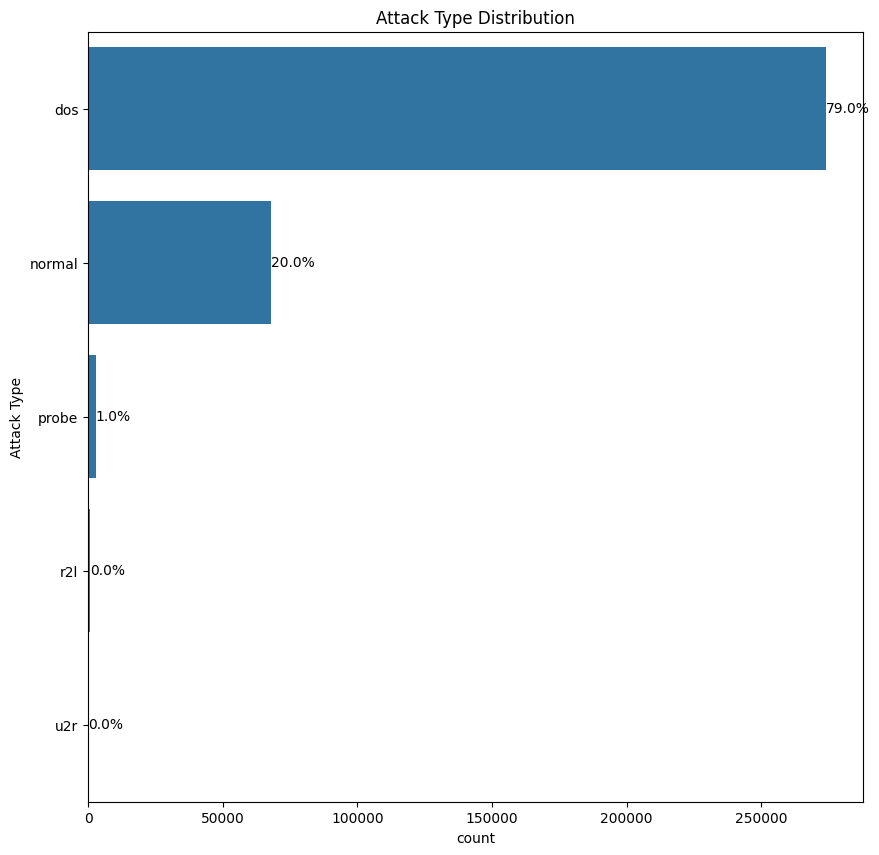

In [11]:
plt.figure(figsize=(10,10))
p = sns.barplot(
    x = 'hot',
    y = 'Attack Type',
    data = train_df.groupby(['Attack Type']).agg(len).reset_index()
)

listlen = train_df.groupby(['Attack Type']).agg(len).reset_index()['hot']
listlen1 = [round(x/(sum(listlen)),2) for x in listlen]

# Corrected line: Changed 'container' to 'containers'
p.bar_label(p.containers[0], labels = [f"{x*100:,}%" for x in listlen1])
plt.title('Attack Type Distribution')
plt.xlabel('count')
plt.show()

serangan terbanyak adalah dos (79%) dan serangan lainnya sangat sedikit.

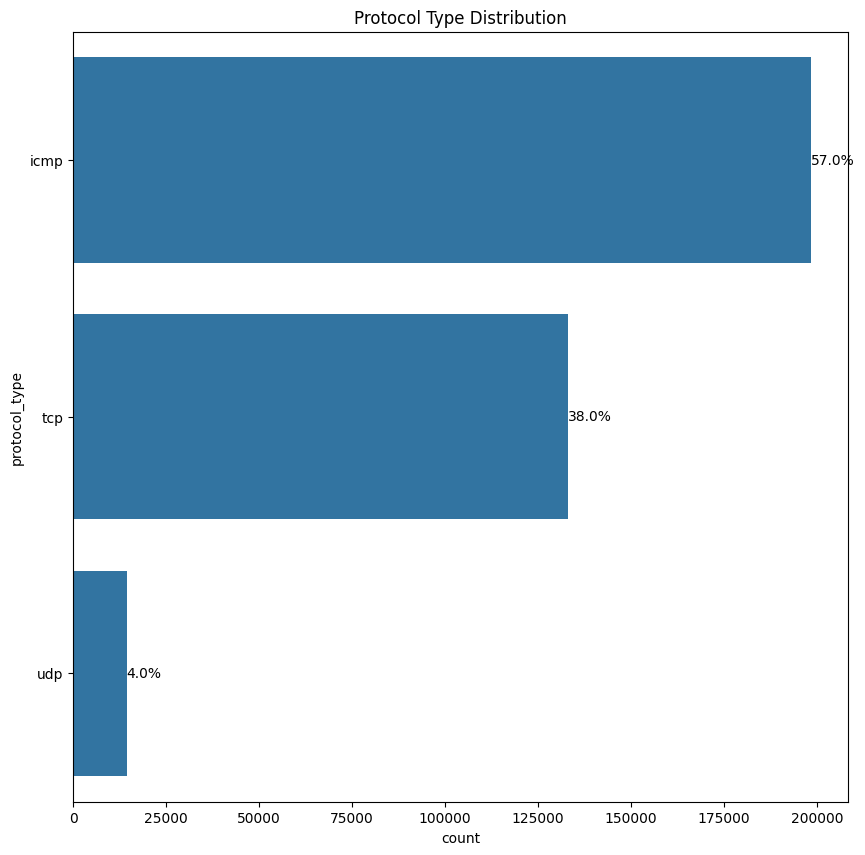

In [12]:
plt.figure(figsize=(10,10))
p = sns.barplot(
    x = 'hot',
    y = 'protocol_type',
    data = train_df.groupby(['protocol_type']).agg(len).reset_index()
)

listlen = train_df.groupby(['protocol_type']).agg(len).reset_index()['hot']
listlen1 = [round(x/(sum(listlen)),2) for x in listlen]

# Corrected line: Changed 'container' to 'containers'
p.bar_label(p.containers[0], labels = [f"{round(x*100,2)}%" for x in listlen1])
plt.title('Protocol Type Distribution')
plt.xlabel('count')
plt.show()

terdapt 3 tipe protokol yakni TCP, UDP dan ICMP dimana paling banyak digunakan adalah ICMP diikuti TCP dan UDP

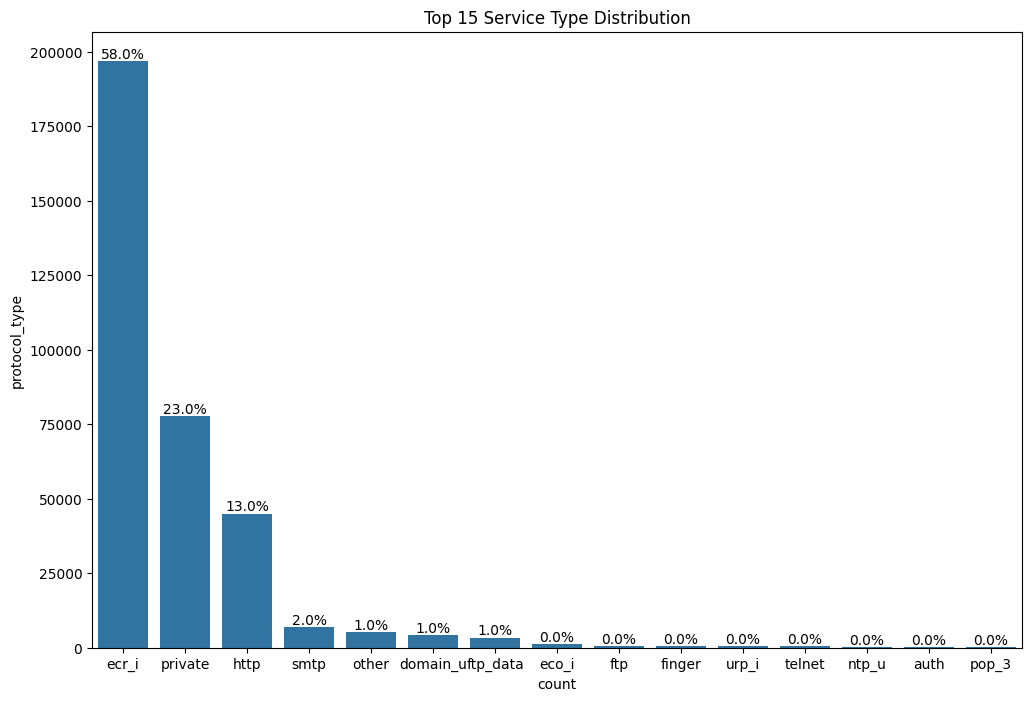

In [13]:
plt.figure(figsize=(12,8))
p = sns.barplot(
    x = 'service',
    y = 'protocol_type',
    data = train_df.groupby(['service']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)[:15]
)

listlen = train_df.groupby(['service']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)[:15]['protocol_type']
listlen1 = [round(x/(sum(listlen)),2) for x in listlen]

# Corrected line: Changed 'container' to 'containers'
p.bar_label(p.containers[0], labels = [f"{round(x*100,2)}%" for x in listlen1])
plt.title('Top 15 Service Type Distribution')
plt.xlabel('count')
plt.show()

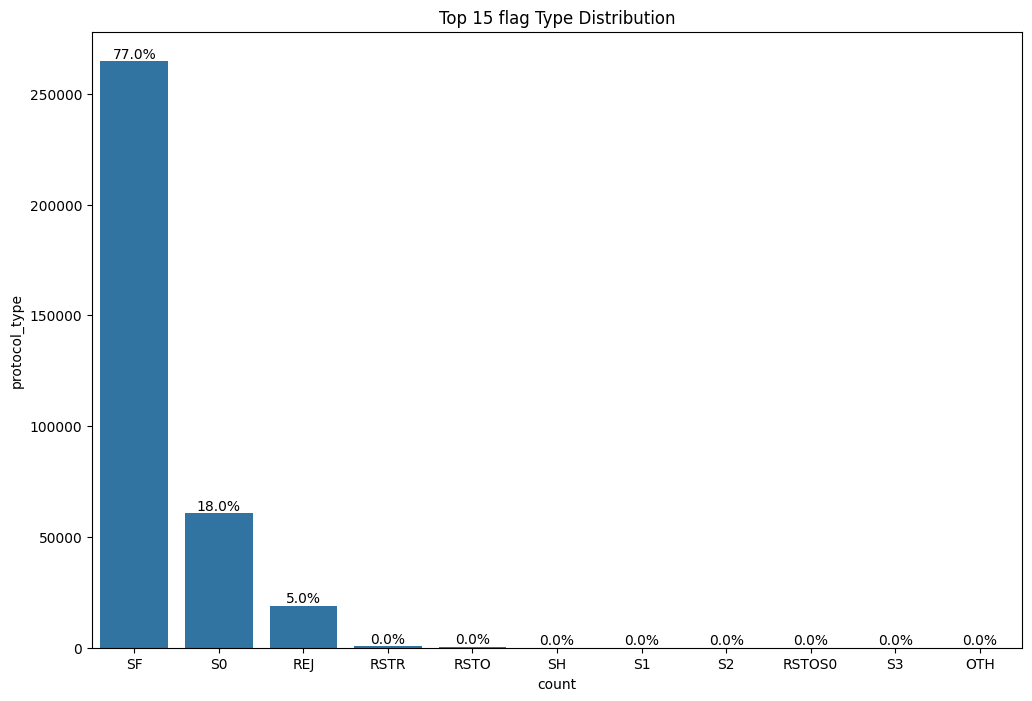

In [14]:
plt.figure(figsize=(12,8))
p = sns.barplot(
    x = 'flag',
    y = 'protocol_type',
    data = train_df.groupby(['flag']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)[:15]
)

listlen = train_df.groupby(['flag']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)[:15]['protocol_type']
listlen1 = [round(x/(sum(listlen)),2) for x in listlen]

# Corrected line: Changed 'container' to 'containers'
p.bar_label(p.containers[0], labels = [f"{round(x*100,2)}%" for x in listlen1])
plt.title('Top 15 flag Type Distribution')
plt.xlabel('count')
plt.show()

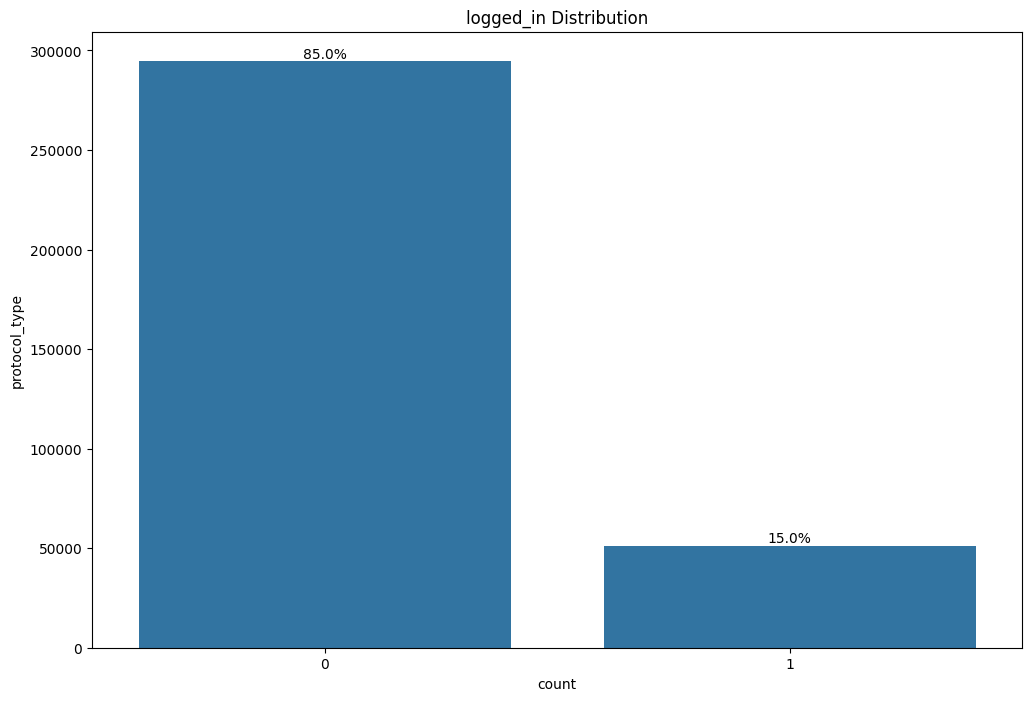

In [15]:
plt.figure(figsize=(12,8))
p = sns.barplot(
    x = 'logged_in',
    y = 'protocol_type',
    data = train_df.groupby(['logged_in']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)
)

listlen = train_df.groupby(['logged_in']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)['protocol_type']
listlen1 = [round(x/(sum(listlen)),2) for x in listlen]

# Corrected line: Changed 'container' to 'containers'
p.bar_label(p.containers[0], labels = [f"{round(x*100,2)}%" for x in listlen1])
plt.title('logged_in Distribution')
plt.xlabel('count')
plt.show()

cuma 15% yang merupakan logged in

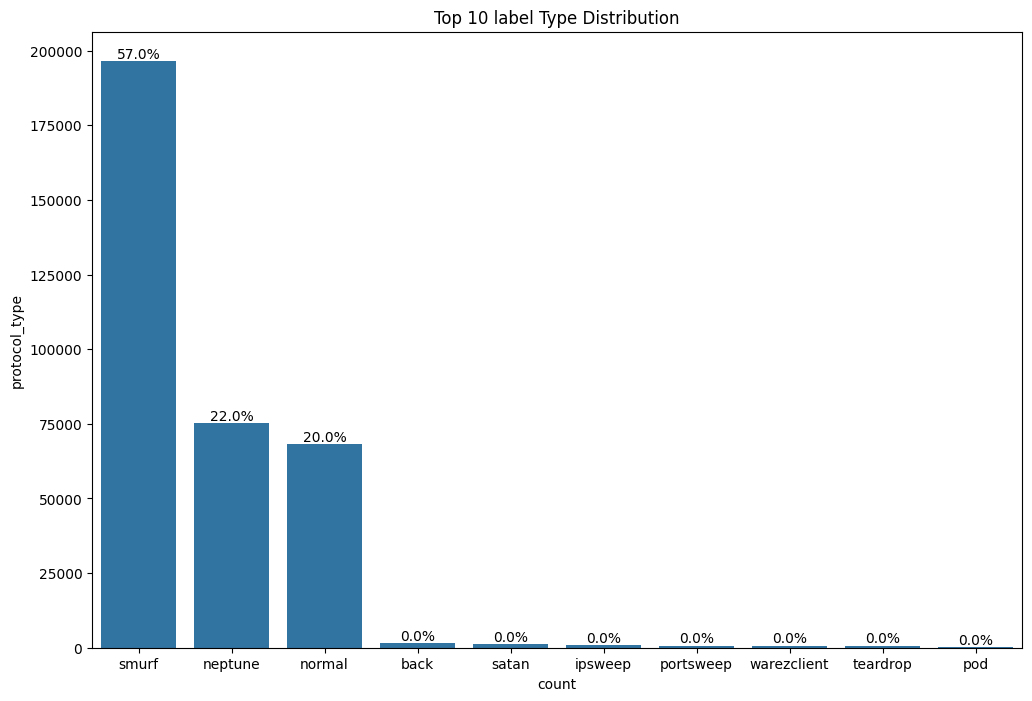

In [16]:
plt.figure(figsize=(12,8))
p = sns.barplot(
    x = 'label',
    y = 'protocol_type',
    data = train_df.groupby(['label']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)[:10]
)

listlen = train_df.groupby(['label']).agg(len).reset_index().sort_values(by = "protocol_type", ascending = False)[:10]['protocol_type']
listlen1 = [round(x/(sum(listlen)),2) for x in listlen]

# Corrected line: Changed 'container' to 'containers'
p.bar_label(p.containers[0], labels = [f"{round(x*100,2)}%" for x in listlen1])
plt.title('Top 10 label Type Distribution')
plt.xlabel('count')
plt.show()

SMURF, nenptune dan normal merupakan 95% data

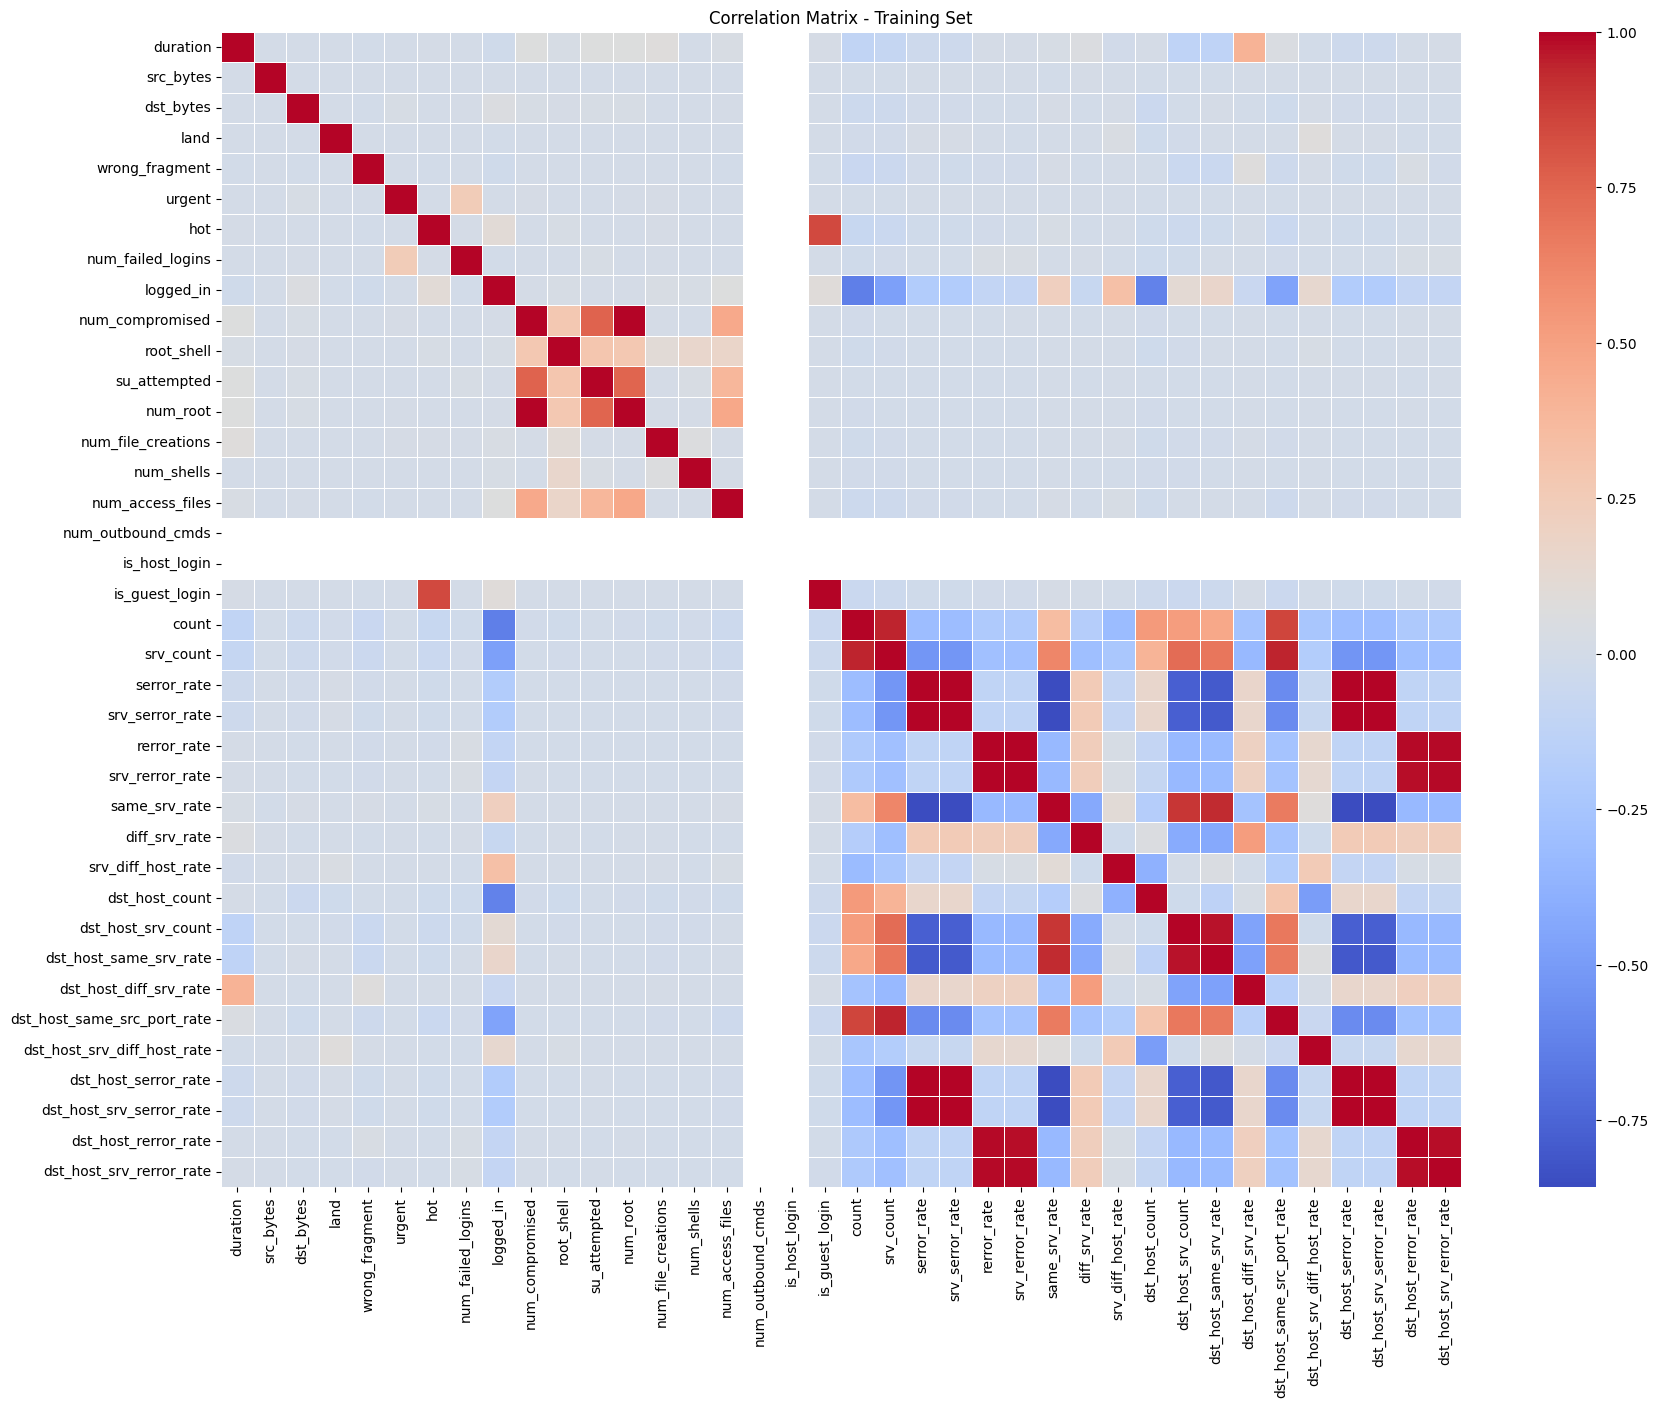

In [17]:
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix - Training Set')
plt.show()

In [18]:
corr_matrix = train_df.corr(numeric_only=True).abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_10_corr = upper_tri.unstack().dropna().sort_values(ascending=False).head(10)
print("Top 10 Correlations:")
for index, value in top_10_corr.items():
    print(f"{index[0]} with {index[1]} with correlation value of {value:.4f}")

Top 10 Correlations:
dst_host_srv_serror_rate with srv_serror_rate with correlation value of 0.9993
dst_host_serror_rate with serror_rate with correlation value of 0.9987
srv_serror_rate with serror_rate with correlation value of 0.9984
dst_host_srv_serror_rate with dst_host_serror_rate with correlation value of 0.9982
dst_host_serror_rate with srv_serror_rate with correlation value of 0.9979
dst_host_srv_serror_rate with serror_rate with correlation value of 0.9979
num_root with num_compromised with correlation value of 0.9951
srv_rerror_rate with rerror_rate with correlation value of 0.9950
dst_host_rerror_rate with rerror_rate with correlation value of 0.9873
dst_host_srv_rerror_rate with srv_rerror_rate with correlation value of 0.9872


bisa jadi ada Multikolinieritas atau redundansi data yang ekstrem

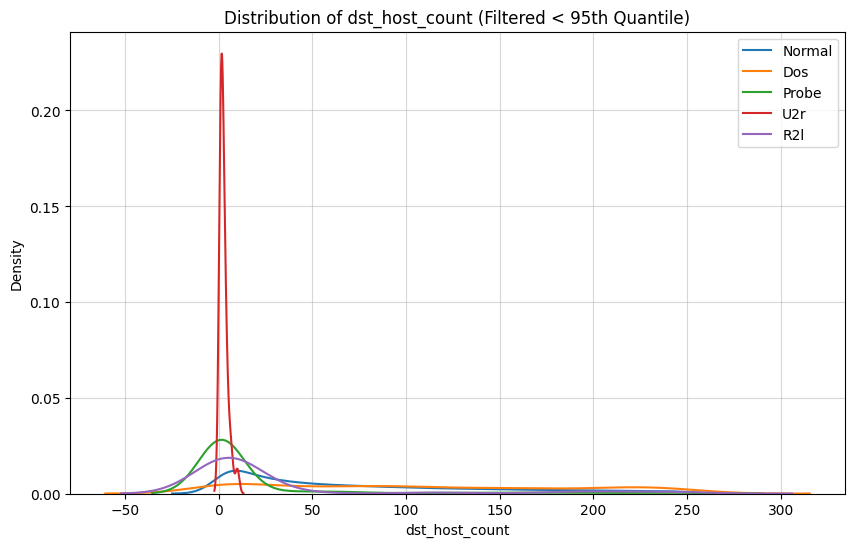

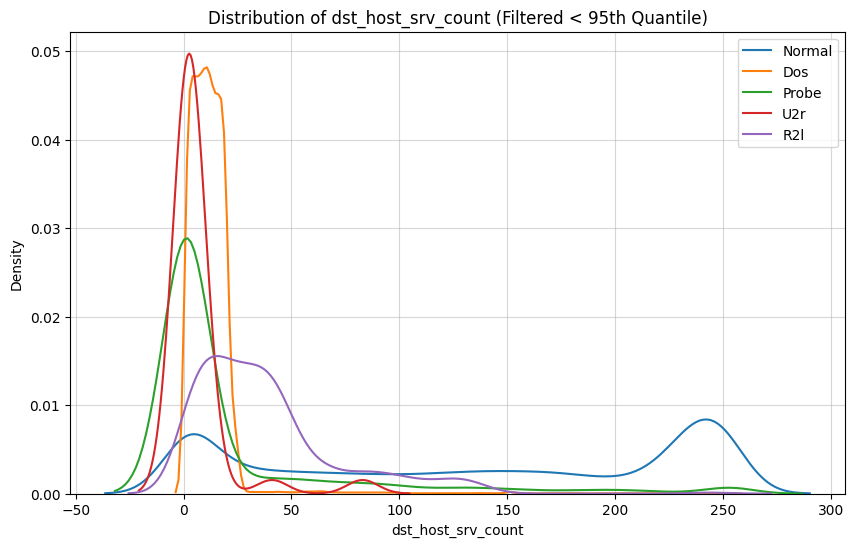

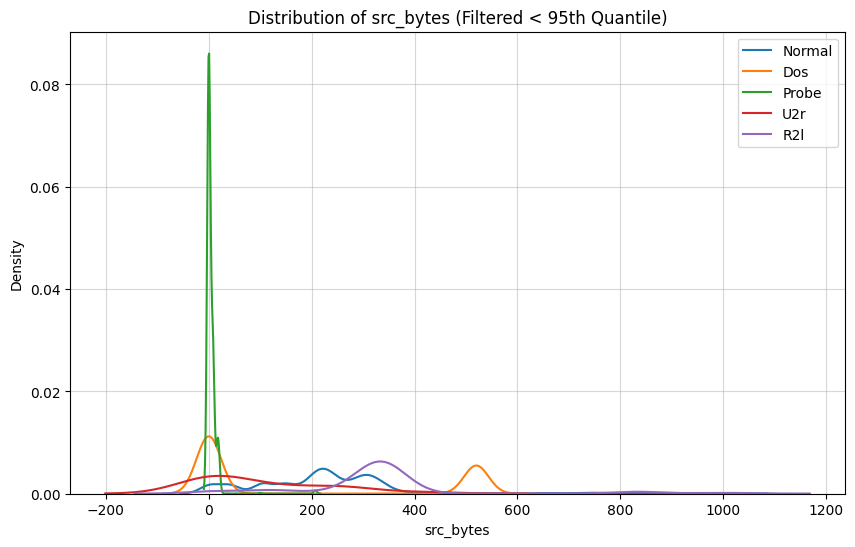

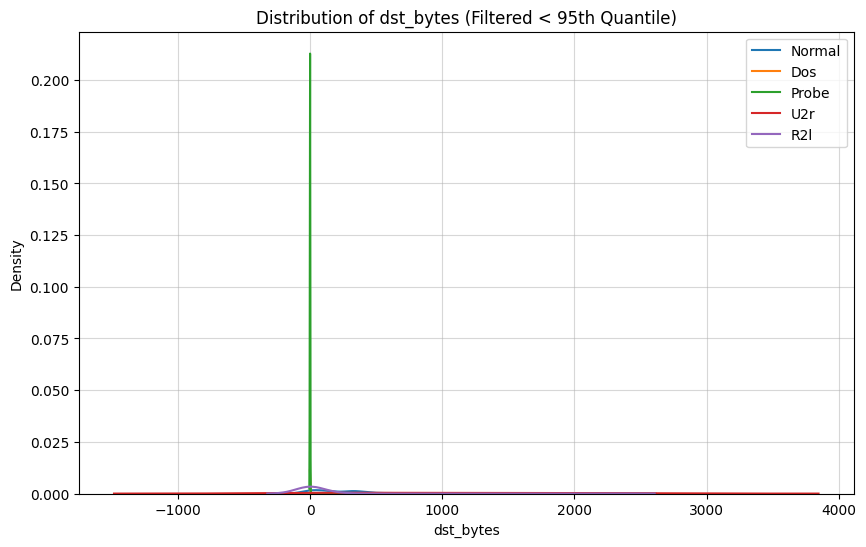

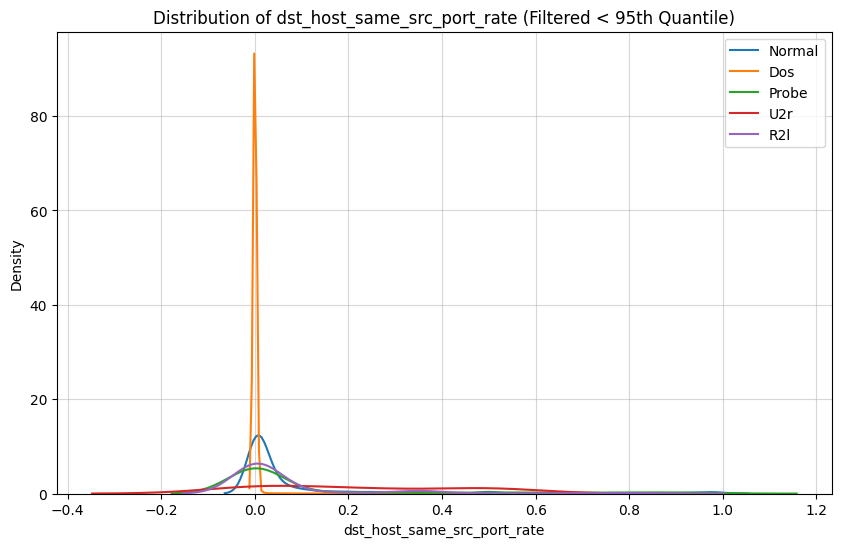

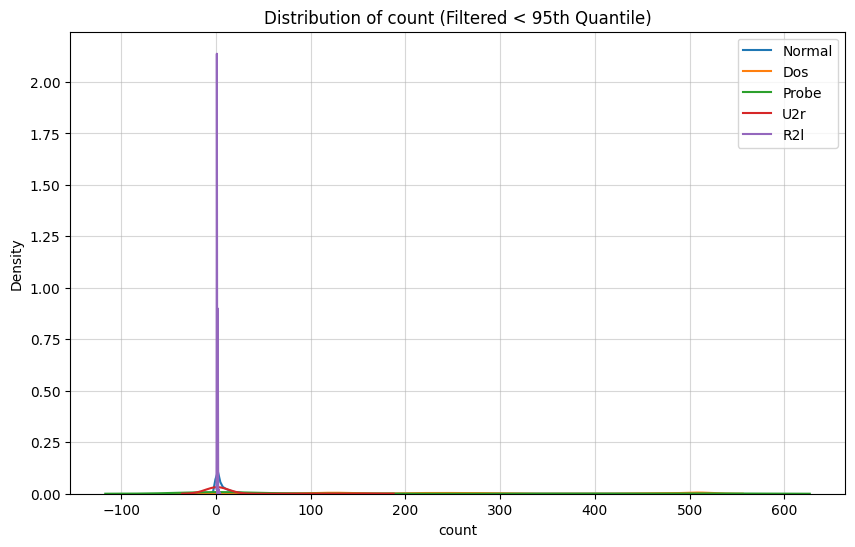

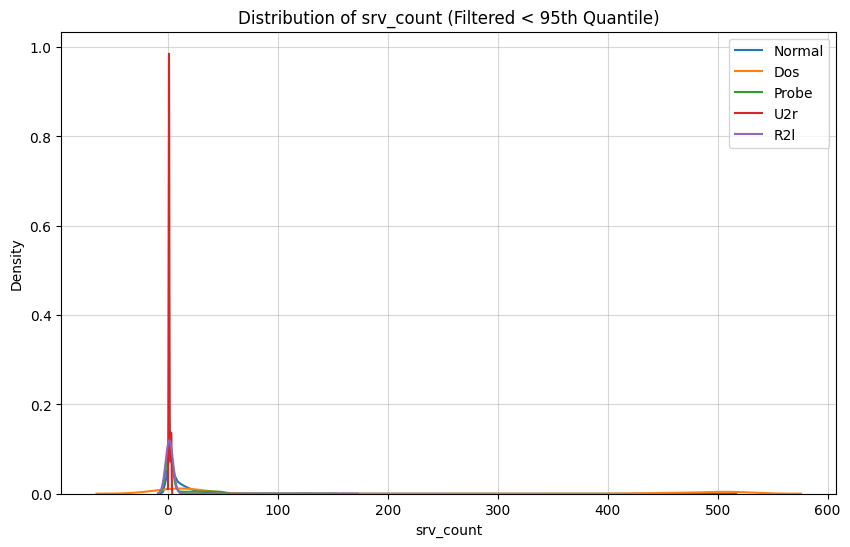

In [19]:
features_to_plot = [
    'dst_host_count', 'dst_host_srv_count', 'src_bytes',
    'dst_bytes', 'dst_host_same_src_port_rate', 'count', 'srv_count'
]


# Daftar kategori serangan untuk looping plot
attack_categories = ['normal', 'dos', 'probe', 'u2r', 'r2l']

for feature in features_to_plot:
    # 1. Filter data untuk membuang 5% outlier teratas
    q95 = train_df[feature].quantile(0.95)
    df_filtered = train_df[train_df[feature] < q95]

    # 2. Setup Figure
    plt.figure(figsize=(10, 6))
    plt.grid(True, alpha=0.5)

    # 3. Plot KDE untuk setiap Attack Type secara manual
    for attack in attack_categories:
        subset = df_filtered[df_filtered['Attack Type'] == attack]

        # Cek apakah data tersedia untuk kategori tersebut agar tidak error
        if not subset.empty:
            sns.kdeplot(subset[feature], label=attack.capitalize())

    # 4. Formatting
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.title(f'Distribution of {feature} (Filtered < 95th Quantile)')
    plt.show()

#Features Selection and Engineering

In [20]:
train_df = train_df.drop(columns=['label'])

In [21]:
#keep columns yang lebih dari 1 unique values
cols_to_keep = [col for col in train_df.columns if train_df[col].nunique() > 1]
train_df = train_df[cols_to_keep]

In [22]:
#menghapus features yang saling terkolerasi

# Menghitung matriks korelasi absolut (hanya numerik)
corr_matrix = train_df.corr(numeric_only=True).abs()

# Mengambil bagian segitiga atas dari matriks korelasi
import numpy as np
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Mencari kolom yang memiliki korelasi > 0.95 dengan kolom lain
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Kolom yang dideteksi redundan (>0.95): {to_drop}")

# Menghapus kolom tersebut dari training dan testing set
train_df.drop(columns=to_drop, inplace=True)

Kolom yang dideteksi redundan (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [23]:
#drop kolom service karena terlalu banyak
train_df.drop(columns=['service'], inplace=True, errors='ignore')

In [24]:
#mapping untuk TARGET (Attack Type) saja
amap = {'normal':0, 'dos':1, 'probe':2, 'r2l':3, 'u2r':4}
train_df['Attack Type'] = train_df['Attack Type'].map(amap)


#One-Hot Encoding untuk fitur kategorikal
categorical_cols = ['protocol_type', 'flag']
#Menggunakan get_dummies
train_df = pd.get_dummies(train_df, columns=categorical_cols)


In [25]:
# Pisahkan target untuk training
X_train = train_df.drop(columns=['Attack Type'])
y_train = train_df['Attack Type']

In [26]:
from sklearn.preprocessing import MinMaxScaler

# Daftar kolom yang akan di-scale sesuai notebook
SCALED_COLUMNS = [
    'src_bytes', 'dst_bytes', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_src_port_rate', 'count', 'srv_count'
]

# Pastikan kolom tersebut ada di dataframe (menghindari error jika ada yang sudah di-drop)
cols_to_scale = [c for c in SCALED_COLUMNS if c in X_train.columns]

scaler = MinMaxScaler()

# Fit dan Transform pada X_train
X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

In [27]:
print(f"Hasil akhir dimensi test_df: {X_train.shape}")
X_train.head()

Hasil akhir dimensi test_df: (345814, 42)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
98169,0,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,1.0,0.00,0.0,255,255,0.00,1.0,0.0,True,False,False,False,False,False,False,False,False,False,False,False,True,False
428760,0,520,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,1.0,0.00,0.0,255,255,0.00,1.0,0.0,True,False,False,False,False,False,False,False,False,False,False,False,True,False
115379,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,143,15,1.0,0.0,0.1,0.06,0.0,255,15,0.06,0.0,0.0,False,True,False,False,False,False,False,False,True,False,False,False,False,False
164324,0,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,510,510,0.0,0.0,1.0,0.00,0.0,255,255,0.00,1.0,0.0,True,False,False,False,False,False,False,False,False,False,False,False,True,False
378682,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,106,11,1.0,0.0,0.1,0.05,0.0,255,11,0.05,0.0,0.0,False,True,False,False,False,False,False,False,True,False,False,False,False,False


In [28]:
#features enggineering untuk data test
test_df = test_df.drop(columns=['label'])

# Menyelaraskan kolom dengan varians rendah (nunique > 1) dari training
test_df = test_df[cols_to_keep]

# Menghapus fitur yang terkolerasi tinggi (hasil deteksi dari train_df)
test_df.drop(columns=to_drop, inplace=True, errors='ignore')

# Menghapus kolom service
test_df.drop(columns=['service'], inplace=True, errors='ignore')

# Mapping Target (Attack Type)
amap = {'normal':0, 'dos':1, 'probe':2, 'r2l':3, 'u2r':4}
test_df['Attack Type'] = test_df['Attack Type'].map(amap)

# One-Hot Encoding untuk fitur kategorikal
categorical_cols = ['protocol_type', 'flag']
test_df = pd.get_dummies(test_df, columns=categorical_cols)

# Sinkronisasi Kolom (Sangat Penting)
# Memastikan test_df memiliki kolom yang sama persis dengan train_df
# Jika ada kolom di train yang tidak ada di test, isi dengan 0
# Jika ada kolom di test yang tidak ada di train, hapus kolom tersebut
test_df = test_df.reindex(columns = train_df.columns, fill_value=0)


print(f"Hasil akhir dimensi test_df: {test_df.shape}")
test_df.head()

Hasil akhir dimensi test_df: (148206, 43)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,Attack Type,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
17431,0,331,660,0,0,0,0,0,1,0,0,0,0,0,0,0,18,26,0.0,0.0,1.00,0.00,0.08,255,255,0.00,0.00,0.00,0,False,True,False,False,False,False,False,False,False,False,False,False,True,False
176182,0,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,1.00,0.00,0.00,255,255,0.00,1.00,0.00,1,True,False,False,False,False,False,False,False,False,False,False,False,True,False
346841,0,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,1.00,0.00,0.00,1,255,0.00,1.00,1.00,2,True,False,False,False,False,False,False,False,False,False,False,False,True,False
373056,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,277,15,1.0,0.0,0.05,0.05,0.00,255,15,0.05,0.00,0.00,1,False,True,False,False,False,False,False,False,True,False,False,False,False,False
23867,0,215,5460,0,0,0,0,0,1,0,0,0,0,0,0,0,6,20,0.0,0.0,1.00,0.00,0.10,6,255,0.00,0.17,0.04,0,False,True,False,False,False,False,False,False,False,False,False,False,True,False


In [29]:
# Pisahkan target untuk testing
X_test = test_df.drop(columns=['Attack Type'])
y_test = test_df['Attack Type']

# Hanya Transform pada X_test (menggunakan parameter dari X_train untuk menghindari leakage)
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [35]:
print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")
print("Apakah kolom sudah sama?", all(X_train.columns == X_test.columns))

Dimensi X_train: (345814, 42)
Dimensi X_test: (148206, 42)
Apakah kolom sudah sama? True


#Modelling

In [40]:
from imblearn.over_sampling import SMOTE

# Menggunakan SMOTE untuk menyeimbangkan jumlah data di setiap kategori
smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Jumlah data setelah SMOTE:\n{y_train_res.value_counts()}")

Jumlah data setelah SMOTE:
Attack Type
1    274021
0    274021
2    274021
3    274021
4    274021
Name: count, dtype: int64


In [41]:
import tensorflow as tf

# Definisi Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_dim=X_train_res.shape[1], activation='relu'), # Hidden Layer 1
    tf.keras.layers.Dense(32, activation='relu'),                              # Hidden Layer 2
    tf.keras.layers.Dense(5, activation='softmax')                             # Output Layer (5 kelas)
])

# Kompilasi Model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,997 (19.52 KB)

 Trainable params: 4,997 (19.52 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Proses Training
history = model.fit(
    X_train_res, y_train_res,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 122s 3ms/step - accuracy: 0.9651 - loss: 0.7786 - val_accuracy: 1.3138e-04 - val_loss: 8.7978
Epoch 2/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 131s 3ms/step - accuracy: 0.9786 - loss: 0.0533 - val_accuracy: 0.0246 - val_loss: 6.7437
Epoch 3/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 105s 3ms/step - accuracy: 0.9797 - loss: 0.0515 - val_accuracy: 0.0861 - val_loss: 7.7410
Epoch 4/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 108s 3ms/step - accuracy: 0.9801 - loss: 0.0505 - val_accuracy: 0.0566 - val_loss: 9.8611
Epoch 5/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 118s 3ms/step - accuracy: 0.9804 - loss: 0.0507 - val_accuracy: 0.0862 - val_loss: 10.3145
Epoch 6/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 116s 3ms/step - accuracy: 0.9809 - loss: 0.0514 - val_accuracy: 0.0518 - val_loss: 12.5501
Epoch 7/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 108s 3ms/step - accuracy: 0.9811 - loss: 0.0552 - val_accuracy: 0.2051 - val_loss: 8.0871
Epoch 8/10
34253/34253 ━━━━━━━━━━━━━━━━━━━━ 111s 3ms/ste

In [43]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi pada data test
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Menampilkan hasil evaluasi
print(classification_report(y_test, y_pred, target_names=['normal', 'dos', 'probe', 'r2l', 'u2r']))

4632/4632 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
              precision    recall  f1-score   support

      normal       1.00      0.95      0.97     29183
         dos       1.00      1.00      1.00    117437
       probe       0.95      0.97      0.96      1232
         r2l       0.18      0.99      0.30       338
         u2r       0.25      0.06      0.10        16

    accuracy                           0.99    148206
   macro avg       0.67      0.79      0.67    148206
weighted avg       1.00      0.99      0.99    148206

